In [73]:

import os
import json
import pandas as pd

In [74]:
!git clone https://github.com/PhonePe/pulse.git

fatal: destination path 'pulse' already exists and is not an empty directory.


In [75]:
path=("/content/pulse/data/aggregated/insurance/country/india/state")
agg_state_list=os.listdir(path)
agg_state_list

['jammu-&-kashmir',
 'nagaland',
 'uttar-pradesh',
 'telangana',
 'arunachal-pradesh',
 'karnataka',
 'chandigarh',
 'lakshadweep',
 'mizoram',
 'bihar',
 'goa',
 'maharashtra',
 'manipur',
 'meghalaya',
 'gujarat',
 'andaman-&-nicobar-islands',
 'delhi',
 'tamil-nadu',
 'jharkhand',
 'sikkim',
 'west-bengal',
 'chhattisgarh',
 'odisha',
 'kerala',
 'rajasthan',
 'tripura',
 'haryana',
 'assam',
 'himachal-pradesh',
 'puducherry',
 'dadra-&-nagar-haveli-&-daman-&-diu',
 'uttarakhand',
 'punjab',
 'madhya-pradesh',
 'andhra-pradesh',
 'ladakh']

In [76]:


path = "/content/pulse/data/aggregated/insurance/country/india/state/"

agg_insurance_state_list = os.listdir(path)

columns = {
    'State': [], 'Year': [], 'Quarter': [],
    'Insurance_Type': [], 'Insurance_Count': [], 'Insurance_Amount': []
}

for state in agg_insurance_state_list:
    p_i = path + state + "/"    #"/content/pulse/data/aggregated/insurance/country/india/state/telangana"
    agg_year = os.listdir(p_i)

    for year in agg_year:
        p_j = p_i + year + "/"      #"/content/pulse/data/aggregated/insurance/country/india/state/telangana/"
        agg_file = os.listdir(p_j)

        for file in agg_file:
            p_k = p_j + file


            with open(p_k, 'r') as f:
                data = json.load(f)


                for i in data['data']['transactionData']:
                    name = i['name']
                    count = i['paymentInstruments'][0]['count']
                    amount = i['paymentInstruments'][0]['amount']


                    columns['State'].append(state)
                    columns['Year'].append(year)
                    columns['Quarter'].append(int(file.strip('.json')))
                    columns['Insurance_Type'].append(name)
                    columns['Insurance_Count'].append(count)
                    columns['Insurance_Amount'].append(amount)

agg_insurance_df = pd.DataFrame(columns)

#agg_insurance_df

In [77]:
agg_insurance_df

,State,Year,Quarter,Insurance_Type,Insurance_Count,Insurance_Amount
0,jammu-&-kashmir,2024,1,Insurance,7313,14695182.0
1,jammu-&-kashmir,2024,4,Insurance,8893,18252110.0
2,jammu-&-kashmir,2024,2,Insurance,7397,14237707.0
3,jammu-&-kashmir,2024,3,Insurance,7597,15554635.0
4,jammu-&-kashmir,2022,1,Insurance,3584,7244267.0
...,...,...,...,...,...,...
677,ladakh,2020,3,Insurance,33,10260.0
678,ladakh,2021,1,Insurance,32,34530.0
679,ladakh,2021,4,Insurance,76,195966.0
680,ladakh,2021,2,Insurance,46,86251.0


#agg_transaction_df

In [78]:
path1 = "/content/pulse/data/aggregated/transaction/country/india/state/"
agg_transaction_state=os.listdir(path1)
agg_transaction_state

columns1 = {"State":[],"Year":[],"Quarter":[],"Transaction_Type": [],"Transaction_Count": [],"Transaction_Amount": []}
for state1 in agg_transaction_state:
  p_state1=path1 + state1 + "/"
  agg_year1=os.listdir(p_state1)
  for year1 in agg_year1:
    j_agg= p_state1+year1+"/"
    agg_file1=os.listdir(j_agg)
    for file_agg1 in agg_file1:

      p_agg1 = j_agg + file_agg1
      with open(p_agg1,'r') as f1:
        data1=json.load(f1)


        for i in data1['data']['transactionData']:
          name = i['name']
          count = i['paymentInstruments'][0]['count']
          amount = i['paymentInstruments'][0]['amount']
          columns1["Year"].append(year1)
          columns1["State"].append(state1)
          columns1['Quarter'].append(int(file_agg1.strip(".json")))
          columns1['Transaction_Type'].append(name)
          columns1['Transaction_Count'].append(count)
          columns1['Transaction_Amount'].append(amount)
agg_transaction_df=pd.DataFrame(columns1)

agg_transaction_df


,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount
0,jammu-&-kashmir,2024,1,Merchant payments,44039688,2.613282e+10
1,jammu-&-kashmir,2024,1,Peer-to-peer payments,21676857,6.349453e+10
2,jammu-&-kashmir,2024,1,Recharge & bill payments,9191925,4.183099e+09
3,jammu-&-kashmir,2024,1,Financial Services,36970,7.780828e+07
4,jammu-&-kashmir,2024,1,Others,170915,7.267369e+07
...,...,...,...,...,...,...
5029,ladakh,2021,3,Peer-to-peer payments,330919,1.917311e+09
5030,ladakh,2021,3,Merchant payments,135108,2.332608e+08
5031,ladakh,2021,3,Recharge & bill payments,121856,5.875008e+07
5032,ladakh,2021,3,Financial Services,900,1.911626e+06


#def_agg_user

In [79]:
path2="/content/pulse/data/aggregated/user/country/india/state/"
agg_user_state=os.listdir(path2)
agg_user_state

columns2={"State":[],"Year":[],"Quarter":[],"Brand":[],"Count":[],"Percentage":[]}
for userstate in agg_user_state:

  p_userstate=path2+userstate + "/"

  agg_user_year=os.listdir(p_userstate)  #"/content/pulse/data/aggregated/user/country/india/state/tamilnadu/"

  for useryear in agg_user_year:
    p_useryear = p_userstate + useryear + "/"   #"/content/pulse/data/aggregated/user/country/india/state/tamilnadu/2018"
    agg_user_file=os.listdir(p_useryear)

    for userfile in agg_user_file:
      p_userfile=p_useryear+userfile

      with open(p_userfile,'r') as f2:
        data2=json.load(f2)
        if data2["data"] is not None:

          if data2["data"]["usersByDevice"] is not None:
            for userdata in data2["data"]["usersByDevice"]:
              brand=userdata['brand']
              count=userdata['count']
              percentage=userdata['percentage']
              columns2["State"].append(userstate)
              columns2['Brand'].append(brand)
              columns2['Count'].append(count)
              columns2['Percentage'].append(percentage)
              columns2['Year'].append(useryear)
              columns2['Quarter'].append(int(userfile.strip(".json")))

def_agg_user=pd.DataFrame(columns2)
def_agg_user



,State,Year,Quarter,Brand,Count,Percentage
0,jammu-&-kashmir,2022,1,Xiaomi,535687,0.345756
1,jammu-&-kashmir,2022,1,Samsung,295630,0.190813
2,jammu-&-kashmir,2022,1,Vivo,242432,0.156476
3,jammu-&-kashmir,2022,1,Oppo,158382,0.102227
4,jammu-&-kashmir,2022,1,Realme,123415,0.079658
...,...,...,...,...,...,...
6727,ladakh,2021,3,Apple,2004,0.024677
6728,ladakh,2021,3,Huawei,1013,0.012474
6729,ladakh,2021,3,Motorola,910,0.011206
6730,ladakh,2021,3,Lenovo,476,0.005861


#df_map_insurance


In [80]:
path = "/content/pulse/data/map/insurance/hover/country/india/state/"
state_list = os.listdir(path)

map_ins_dict = {"State": [], "Year": [], "Quarter": [], "District": [], "Count": [], "Amount": []}

for statemap in state_list:
    p_state = path + statemap + "/"
    year_list = os.listdir(p_state)

    for year in year_list:
        p_year = p_state + year + "/"
        file_list = os.listdir(p_year)

        for file in file_list:
            p_file = p_year + file

            with open(p_file, 'r') as f:
                data = json.load(f)

            for entry in data['data']['hoverDataList']:
                map_ins_dict["State"].append(statemap)
                map_ins_dict["Year"].append(year)
                map_ins_dict["Quarter"].append(file.strip('.json'))
                map_ins_dict["District"].append(entry['name'])
                map_ins_dict["Count"].append(entry['metric'][0]['count'])
                map_ins_dict["Amount"].append(entry['metric'][0]['amount'])
df_map_insurance =pd.DataFrame(map_ins_dict)
df_map_insurance


,State,Year,Quarter,District,Count,Amount
0,jammu-&-kashmir,2024,1,muzaffarabad district,1,5516.0
1,jammu-&-kashmir,2024,1,doda district,171,387272.0
2,jammu-&-kashmir,2024,1,samba district,392,775248.0
3,jammu-&-kashmir,2024,1,mirpur district,29,53282.0
4,jammu-&-kashmir,2024,1,srinagar district,709,1399799.0
...,...,...,...,...,...,...
13871,ladakh,2021,4,leh ladakh district,58,157274.0
13872,ladakh,2021,2,kargil district,12,32158.0
13873,ladakh,2021,2,leh ladakh district,34,54093.0
13874,ladakh,2021,3,kargil district,16,23756.0


#df_map_transaction


In [81]:
pathmaptrans="/content/pulse/data/map/transaction/hover/country/india/state/"
maptranscationstate = os.listdir(pathmaptrans)
maptranscationstate

mapcolumn = {"state":[],"year":[],"Quarter":[], "District": [], "Count": [], "Amount": []}

for state_trans in maptranscationstate:
  p_state_trans = pathmaptrans + state_trans + "/"
  year_trans = os.listdir(p_state_trans)

  for year_transcation in year_trans:
    p_year_trans = p_state_trans + year_transcation + "/"
    file_trans = os.listdir(p_year_trans)

    for file_transcation in file_trans:
      p_file_trans = p_year_trans + file_transcation

      with open (p_file_trans,'r') as mapf2:
        data3 = json.load(mapf2)

        for i in data3['data']['hoverDataList']:
          mapcolumn['District'].append(i['name'])
          mapcolumn['Count'].append(i['metric'][0]['count'])
          mapcolumn['Amount'].append(i['metric'][0]['amount'])
          mapcolumn['state'].append(state_trans)
          mapcolumn['year'].append(year_transcation)
          mapcolumn['Quarter'].append(int(file_transcation.strip('.json')))

df_map_transaction =pd.DataFrame(mapcolumn)
df_map_transaction



,state,year,Quarter,District,Count,Amount
0,jammu-&-kashmir,2024,1,muzaffarabad district,40747,6.609396e+07
1,jammu-&-kashmir,2024,1,doda district,1698725,1.803821e+09
2,jammu-&-kashmir,2024,1,samba district,3596063,4.686291e+09
3,jammu-&-kashmir,2024,1,mirpur district,232220,4.124138e+08
4,jammu-&-kashmir,2024,1,srinagar district,6986808,9.356470e+09
...,...,...,...,...,...,...
20599,ladakh,2021,4,leh ladakh district,495230,1.736887e+09
20600,ladakh,2021,2,kargil district,91914,2.849853e+08
20601,ladakh,2021,2,leh ladakh district,307802,1.142274e+09
20602,ladakh,2021,3,kargil district,128949,4.445214e+08


#df_map_user


In [82]:
path_user ="/content/pulse/data/map/user/hover/country/india/state/"
stateuser = os.listdir(path_user)
stateuser
columnmapuser = {"State": [], "Year": [], "Quarter": [], "District": [], "RegisteredUsers": [], "AppOpens": []}

for mapuserstate in stateuser:
  statemapuser = path_user + mapuserstate + "/"
  state_map_user = os.listdir(statemapuser)

  for mapuseryear in state_map_user:
    yearmapuser = statemapuser + mapuseryear + "/"
    year_map_user =os.listdir(yearmapuser)

    for mapuserfile in year_map_user:
      filemapuser = yearmapuser + mapuserfile

      with open (filemapuser,'r') as mf3:
        datamap4 = json.load(mf3)

        for imap ,value in datamap4['data']['hoverData'].items():
          columnmapuser['State'].append(mapuserstate)
          columnmapuser['Year'].append(mapuseryear)
          columnmapuser['Quarter'].append(int(mapuserfile.strip('.json')))
          columnmapuser['District'].append(imap)
          columnmapuser['RegisteredUsers'].append(value['registeredUsers'])
          columnmapuser['AppOpens'].append(value['appOpens'])

df_map_user = pd.DataFrame(columnmapuser)
df_map_user




,State,Year,Quarter,District,RegisteredUsers,AppOpens
0,jammu-&-kashmir,2024,1,muzaffarabad district,768,1652016
1,jammu-&-kashmir,2024,1,doda district,51616,23936684
2,jammu-&-kashmir,2024,1,samba district,99768,10842502
3,jammu-&-kashmir,2024,1,mirpur district,10169,8075855
4,jammu-&-kashmir,2024,1,srinagar district,194780,4072112
...,...,...,...,...,...,...
20603,ladakh,2021,4,leh ladakh district,67049,2091376
20604,ladakh,2021,2,kargil district,17077,1494139
20605,ladakh,2021,2,leh ladakh district,57971,2897493
20606,ladakh,2021,3,kargil district,18577,2373080


#df_top_insurance

In [83]:
path = "/content/pulse/data/top/insurance/country/india/state/"
top_ins_states = os.listdir(path)


top_ins_dict = {'State': [], 'Year': [], 'Quarter': [], 'Entity_Name': [], 'Count': [], 'Amount': []}

for state in top_ins_states:
    state_path = os.path.join(path, state)
    years = os.listdir(state_path)

    for year in years:
        year_path = os.path.join(state_path, year)
        files = os.listdir(year_path)

        for file in files:
            file_path = os.path.join(year_path, file)
            with open(file_path, 'r') as f:
                data = json.load(f)


                for entry in data['data']['districts']:
                    entity = entry['entityName']
                    count = entry['metric']['count']
                    amount = entry['metric']['amount']

                    top_ins_dict['State'].append(state)
                    top_ins_dict['Year'].append(year)
                    top_ins_dict['Quarter'].append(int(file.strip('.json')))
                    top_ins_dict['Entity_Name'].append(entity)
                    top_ins_dict['Count'].append(count)
                    top_ins_dict['Amount'].append(amount)
df_top_insurance = pd.DataFrame(top_ins_dict)
df_top_insurance

,State,Year,Quarter,Entity_Name,Count,Amount
0,jammu-&-kashmir,2024,1,jammu,2285,4279724.0
1,jammu-&-kashmir,2024,1,srinagar,709,1399799.0
2,jammu-&-kashmir,2024,1,kathua,426,806125.0
3,jammu-&-kashmir,2024,1,udhampur,420,746405.0
4,jammu-&-kashmir,2024,1,samba,392,775248.0
...,...,...,...,...,...,...
5603,ladakh,2021,4,kargil,18,38692.0
5604,ladakh,2021,2,leh ladakh,34,54093.0
5605,ladakh,2021,2,kargil,12,32158.0
5606,ladakh,2021,3,leh ladakh,176,150296.0


#df_top_transaction

In [84]:
pathtop2 = "/content/pulse/data/top/transaction/country/india/state/"
patht2 = os.listdir(pathtop2)

# Initialize separate dictionaries for districts and pincodes
column_districts = {'State': [], 'Year': [], 'Quarter': [], 'Entity_Name': [], 'Count': [], 'Amount': []}
column_pincodes = {'State': [], 'Year': [], 'Quarter': [], 'Pincode': [], 'Count': [], 'Amount': []}

for topaggstate in patht2:
  top_agg_state = pathtop2 + topaggstate + "/"
  top_aggregate_state = os.listdir(top_agg_state)

  for topaggyear in top_aggregate_state:
    top_agg_year = top_agg_state + topaggyear + "/"
    top_aggregate_year = os.listdir(top_agg_year)

    for topaggfile in top_aggregate_year:
      top_agg_file = top_agg_year + topaggfile

      with open (top_agg_file ,'r') as topag1:
        daattopagg = json.load(topag1)

        # Extract District Data
        if 'districts' in daattopagg['data']:
            for topjson in daattopagg['data']['districts']:
              column_districts['State'].append(topaggstate)
              column_districts['Year'].append(topaggyear)
              column_districts['Quarter'].append(int(topaggfile.strip('.json')))
              column_districts['Entity_Name'].append(topjson['entityName'])
              column_districts['Count'].append(topjson['metric']['count'])
              column_districts['Amount'].append(topjson['metric']['amount'])

        # Extract Pincode Data
        if 'pincodes' in daattopagg['data']:
            for pinjson in daattopagg['data']['pincodes']:
              column_pincodes['State'].append(topaggstate)
              column_pincodes['Year'].append(topaggyear)
              column_pincodes['Quarter'].append(int(topaggfile.strip('.json')))
              column_pincodes['Pincode'].append(pinjson['entityName'])
              column_pincodes['Count'].append(pinjson['metric']['count'])
              column_pincodes['Amount'].append(pinjson['metric']['amount'])

# Create DataFrames from the separated dictionaries
df_top_transaction = pd.DataFrame(column_districts)
df_top_transaction_pincode = pd.DataFrame(column_pincodes)


#df_top_user


In [85]:
pathusertop ='/content/pulse/data/top/user/country/india/state/'
topuserstate = os.listdir(pathusertop)
topuserstate
columnstopuser ={'State':[],'Year':[],"Quarter":[],"Name":[],'RegisteredUsers':[]}
for p_topuserstate in topuserstate:
  top_user_state = pathusertop + p_topuserstate + '/'
  top_user_year = os.listdir(top_user_state)

  for topuseryear in top_user_year:
    top_user_year = top_user_state + topuseryear +'/'
    top_user_file = os.listdir(top_user_year)

    for topuserfile in top_user_file:
      p_top_user_file = top_user_year + topuserfile
      with open(p_top_user_file,'r') as tuf1:
        datatuf1 =json.load(tuf1)

        for topuserjson in datatuf1['data']['districts']:
          name = topuserjson['name']
          registeredusers = topuserjson['registeredUsers']

          columnstopuser['State'].append(p_topuserstate)
          columnstopuser['Year'].append(topuseryear)
          columnstopuser['Quarter'].append(int(topuserfile.strip('.json')))
          columnstopuser['Name'].append(name)
          columnstopuser['RegisteredUsers'].append(registeredusers)



df_top_user = pd.DataFrame(columnstopuser)
df_top_user


,State,Year,Quarter,Name,RegisteredUsers
0,jammu-&-kashmir,2024,1,jammu,563905
1,jammu-&-kashmir,2024,1,srinagar,194780
2,jammu-&-kashmir,2024,1,baramulla,169476
3,jammu-&-kashmir,2024,1,budgam,126146
4,jammu-&-kashmir,2024,1,kathua,119369
...,...,...,...,...,...
8291,ladakh,2021,4,kargil,20008
8292,ladakh,2021,2,leh ladakh,57971
8293,ladakh,2021,2,kargil,17077
8294,ladakh,2021,3,leh ladakh,62633


In [86]:
import sqlite3

conn = sqlite3.connect("phonpe_project.bd")
cursor = conn.cursor()

path_user_top = '/content/pulse/data/top/user/country/india/state/'
states_list = os.listdir(path_user_top)

user_pin_dict = {'State': [], 'Year': [], 'Quarter': [], 'Pincode': [], 'RegisteredUsers': []}

for state in states_list:
    state_path = os.path.join(path_user_top, state)
    if os.path.isdir(state_path):
        years = os.listdir(state_path)
        for year in years:
            year_path = os.path.join(state_path, year)
            if os.path.isdir(year_path):
                files = os.listdir(year_path)
                for file in files:
                    file_path = os.path.join(year_path, file)
                    with open(file_path, 'r') as f:
                        data = json.load(f)
                        for pin in data['data']['pincodes']:
                            user_pin_dict['State'].append(state)
                            user_pin_dict['Year'].append(year)
                            user_pin_dict['Quarter'].append(int(file.strip('.json')))
                            user_pin_dict['Pincode'].append(pin['name'])
                            user_pin_dict['RegisteredUsers'].append(pin['registeredUsers'])

df_top_user_pincodes = pd.DataFrame(user_pin_dict)

# Create and populate the Top_User_Pincodes table
cursor.execute('''CREATE TABLE IF NOT EXISTS Top_User_Pincodes (State VARCHAR(255), Year INT, Quarter INT,
Pincode VARCHAR(255), RegisteredUsers INT)''')
conn.commit()

for itup, rowtup in df_top_user_pincodes.iterrows():
  sql ="INSERT INTO Top_User_Pincodes VALUES (?,?,?,?,?)"
  cursor.execute(sql,tuple(rowtup))
conn.commit()

# connection into sql

In [87]:
import sqlite3


In [88]:
conn = sqlite3.connect("phonpe_project.bd")
cursor = conn.cursor()

In [89]:
cursor.execute('''CREATE TABLE IF NOT EXISTS Aggregated_Insurance (
                    State VARCHAR(255),
                    Year INT,
                    Quarter INT,
                    Insurance_Type VARCHAR(255),
                    Insurance_Count BIGINT,
                    Insurance_Amount FLOAT
                )''')
conn.commit()

# Aggregated_Insurance

#

In [90]:
for ii, roww in agg_insurance_df.iterrows():
    sql = "INSERT INTO Aggregated_Insurance VALUES (?,?,?,?,?,?)"
    cursor.execute(sql, tuple(roww))

conn.commit()

In [91]:
dataagg1=[]
cursor.execute("SELECT * FROM Aggregated_Insurance ")
for row in cursor:
    dataagg1.append(row)
dataagg1



[('jammu-&-kashmir', 2024, 1, 'Insurance', 7313, 14695182.0),
 ('jammu-&-kashmir', 2024, 4, 'Insurance', 8893, 18252110.0),
 ('jammu-&-kashmir', 2024, 2, 'Insurance', 7397, 14237707.0),
 ('jammu-&-kashmir', 2024, 3, 'Insurance', 7597, 15554635.0),
 ('jammu-&-kashmir', 2022, 1, 'Insurance', 3584, 7244267.0),
 ('jammu-&-kashmir', 2022, 4, 'Insurance', 5031, 10111183.0),
 ('jammu-&-kashmir', 2022, 2, 'Insurance', 4071, 7729792.0),
 ('jammu-&-kashmir', 2022, 3, 'Insurance', 4794, 8281826.0),
 ('jammu-&-kashmir', 2023, 1, 'Insurance', 4555, 10275877.0),
 ('jammu-&-kashmir', 2023, 4, 'Insurance', 6264, 13932309.0),
 ('jammu-&-kashmir', 2023, 2, 'Insurance', 5262, 10974839.0),
 ('jammu-&-kashmir', 2023, 3, 'Insurance', 5453, 10975874.0),
 ('jammu-&-kashmir', 2020, 4, 'Insurance', 647, 734861.0),
 ('jammu-&-kashmir', 2020, 2, 'Insurance', 206, 48484.0),
 ('jammu-&-kashmir', 2020, 3, 'Insurance', 441, 133339.0),
 ('jammu-&-kashmir', 2021, 1, 'Insurance', 1105, 1546288.0),
 ('jammu-&-kashmir', 2

#Aggregated_Transaction

In [92]:
cursor.execute('''CREATE TABLE IF NOT EXISTS Aggregated_Transaction (
                    State VARCHAR(255),
                    Year INT,
                    Quarter INT,
                    Transaction_Type VARCHAR(255),
                    Transaction_Count BIGINT,
                    Transaction_Amount FLOAT
                )''')
conn.commit()

In [93]:
for i, row in agg_transaction_df.iterrows():
    sql = "INSERT INTO Aggregated_Transaction VALUES (?,?,?,?,?,?)"
    cursor.execute(sql, tuple(row))

conn.commit()

In [94]:
dataagg2=[]
cursor.execute("SELECT * FROM Aggregated_Transaction  LIMIT 5")
for row in cursor:
    dataagg2.append(row)
dataagg2

[('jammu-&-kashmir', 2024, 1, 'Merchant payments', 44039688, 26132817115.0),
 ('jammu-&-kashmir',
  2024,
  1,
  'Peer-to-peer payments',
  21676857,
  63494530507.0),
 ('jammu-&-kashmir',
  2024,
  1,
  'Recharge & bill payments',
  9191925,
  4183099352.0),
 ('jammu-&-kashmir', 2024, 1, 'Financial Services', 36970, 77808277.0),
 ('jammu-&-kashmir', 2024, 1, 'Others', 170915, 72673690.0)]

#Aggregated_User

In [95]:
#"State":[],"Year":[],"Quarter":[],"Brand":[],"Count":[],"Percentage":[]
cursor.execute('''CREATE TABLE IF NOT EXISTS Aggregated_User (
  State VARCHAR(255),
  Year INT,
  Quarter INT,
  Brand VARCHAR(255),
  Count BIGINT,
  Percentage FLOAT
)''')
conn.commit()

In [96]:
for ia ,rowa in def_agg_user.iterrows():
  sql = "INSERT INTO Aggregated_User VALUES (?,?,?,?,?,?)"
  cursor.execute(sql,tuple(rowa))
conn.commit()


In [97]:
dataagg3=[]
cursor.execute("SELECT * FROM Aggregated_User  LIMIT 5")
for rowa in cursor:
    dataagg3.append(rowa)
dataagg3

[('jammu-&-kashmir', 2022, 1, 'Xiaomi', 535687, 0.34575620272119384),
 ('jammu-&-kashmir', 2022, 1, 'Samsung', 295630, 0.19081274365528103),
 ('jammu-&-kashmir', 2022, 1, 'Vivo', 242432, 0.1564763896419074),
 ('jammu-&-kashmir', 2022, 1, 'Oppo', 158382, 0.10222678336302378),
 ('jammu-&-kashmir', 2022, 1, 'Realme', 123415, 0.07965752717321148)]

#Map_Insurance

In [98]:
# df_map_insurance
# "State": [], "Year": [], "Quarter": [], "District": [], "Count": [], "Amount": []}
cursor.execute (''' CREATE TABLE IF NOT EXISTS Map_Insurance (
State VARCHAR(255),
Year INT,
Quarter INT,
District VARCHAR(255),
Count BIGINT,Amount FLOAT
)''')
conn.commit()

In [99]:
for im , rowm in df_map_insurance.iterrows():
  sql = "INSERT INTO Map_Insurance VALUES (?,?,?,?,?,?)"
  cursor.execute(sql,tuple(rowm))
conn.commit()

In [100]:
datam1=[]
cursor.execute("SELECT * FROM Map_Insurance  LIMIT 5")
for rowm1 in cursor:
    datam1.append(rowm1)
datam1

[('jammu-&-kashmir', 2024, 1, 'muzaffarabad district', 1, 5516.0),
 ('jammu-&-kashmir', 2024, 1, 'doda district', 171, 387272.0),
 ('jammu-&-kashmir', 2024, 1, 'samba district', 392, 775248.0),
 ('jammu-&-kashmir', 2024, 1, 'mirpur district', 29, 53282.0),
 ('jammu-&-kashmir', 2024, 1, 'srinagar district', 709, 1399799.0)]

#Map_Transaction

---



In [101]:
# "state":[],"year":[],"Quarter":[], "District": [], "Count": [], "Amount": []
# df_map_transaction

cursor.execute(''' CREATE TABLE IF NOT EXISTS Map_Transaction
 (
  state VARCHAR(255),
  year INT,
  Quarter INT,
  District VARCHAR(255), Count BIGINT, Amount FLOAT
)''')
conn.commit()


In [102]:
for i2, row2 in df_map_transaction.iterrows():
  sql = "INSERT   INTO Map_Transaction VALUES (?,?,?,?,?,?)"
  cursor.execute(sql, tuple(row2))
conn.commit()


In [103]:
datam2=[]
cursor.execute("SELECT * FROM Map_Transaction LIMIT 5")
for rowm2 in cursor:
    datam2.append(rowm2)
datam2

[('jammu-&-kashmir', 2024, 1, 'muzaffarabad district', 40747, 66093964.0),
 ('jammu-&-kashmir', 2024, 1, 'doda district', 1698725, 1803820761.0),
 ('jammu-&-kashmir', 2024, 1, 'samba district', 3596063, 4686290713.0),
 ('jammu-&-kashmir', 2024, 1, 'mirpur district', 232220, 412413801.0),
 ('jammu-&-kashmir', 2024, 1, 'srinagar district', 6986808, 9356469544.0)]

#Map_User

> Add blockquote



In [104]:
#columnmapuser = {"State": [], "Year": [], "Quarter": [], "District": [], "RegisteredUsers": [], "AppOpens": []}
#df_map_user
cursor.execute('''CREATE TABLE IF NOT EXISTS Map_User (State VARCHAR(255), Year INT, Quarter INT,
District VARCHAR(255), RegisteredUsers INT, AppOpens BIGINT )''')
conn.commit()

In [105]:
import pandas as pd
# Execute the query and load results into a DataFrame to show them
df_view_map_user = pd.read_sql_query("SELECT * FROM Map_User LIMIT 10", conn)
display(df_view_map_user)

,State,Year,Quarter,District,RegisteredUsers,AppOpens
0,jammu-&-kashmir,2024,1,muzaffarabad district,768,1652016
1,jammu-&-kashmir,2024,1,doda district,51616,23936684
2,jammu-&-kashmir,2024,1,samba district,99768,10842502
3,jammu-&-kashmir,2024,1,mirpur district,10169,8075855
4,jammu-&-kashmir,2024,1,srinagar district,194780,4072112
5,jammu-&-kashmir,2024,1,baramulla district,169476,19679158
6,jammu-&-kashmir,2024,1,jammu district,563905,25557799
7,jammu-&-kashmir,2024,1,ganderbal district,41862,11344697
8,jammu-&-kashmir,2024,1,udhampur district,111438,32658305
9,jammu-&-kashmir,2024,1,bandipore district,45943,5171388


In [106]:
for im3, rowm3 in df_map_user.iterrows():
  sql ="INSERT INTO Map_User VALUES (?,?,?,?,?,?)"
  cursor.execute(sql,tuple(rowm3))
conn.commit()

In [107]:
#cursor.execute("select state,sum(RegisteredUsers)  as total_users from  datam3 where Year = 2023 and Quater = 1  group by State Total_Users DESC;  ")

In [108]:
datam3=[]
cursor.execute("SELECT * FROM Map_Transaction LIMIT 5")
for rowmU3 in cursor:
    datam3.append(rowmU3)
datam3

[('jammu-&-kashmir', 2024, 1, 'muzaffarabad district', 40747, 66093964.0),
 ('jammu-&-kashmir', 2024, 1, 'doda district', 1698725, 1803820761.0),
 ('jammu-&-kashmir', 2024, 1, 'samba district', 3596063, 4686290713.0),
 ('jammu-&-kashmir', 2024, 1, 'mirpur district', 232220, 412413801.0),
 ('jammu-&-kashmir', 2024, 1, 'srinagar district', 6986808, 9356469544.0)]

#Top_Insurance

In [109]:
#df_top_insurance
#top_ins_dict = {'State': [], 'Year': [], 'Quarter': [], 'Entity_Name': [], 'Count': [], 'Amount': []}
cursor.execute('''CREATE TABLE IF NOT EXISTS Top_Insurance (State VARCHAR(255),Year INT, Quarter INT,
Entity_Name VARCHAR(255),Count INT ,Amount INT )''')
conn.commit()

In [110]:
for it1, rowt1 in df_top_insurance.iterrows():
  sql ="INSERT INTO Top_Insurance VALUES (?,?,?,?,?,?)"
  cursor.execute(sql,tuple(rowt1))
conn.commit

<function Connection.commit()>

In [111]:
datatt1=[]
cursor.execute("SELECT * FROM Top_Insurance LIMIT 5")
for rowtt1 in cursor:
    datatt1.append(rowtt1)
datatt1

[('jammu-&-kashmir', 2024, 1, 'jammu', 2285, 4279724),
 ('jammu-&-kashmir', 2024, 1, 'srinagar', 709, 1399799),
 ('jammu-&-kashmir', 2024, 1, 'kathua', 426, 806125),
 ('jammu-&-kashmir', 2024, 1, 'udhampur', 420, 746405),
 ('jammu-&-kashmir', 2024, 1, 'samba', 392, 775248)]

#Top_Transaction

In [112]:
# Create tables for both Districts and Pincodes
cursor.execute('''CREATE TABLE IF NOT EXISTS Top_Transaction (State VARCHAR(255), Year INT, Quarter INT,
Entity_Name VARCHAR(255), Count BIGINT, Amount FLOAT)''')

cursor.execute('''CREATE TABLE IF NOT EXISTS Top_Transaction_Pincodes (State VARCHAR(255), Year INT, Quarter INT,
Pincode VARCHAR(255), Count BIGINT, Amount FLOAT)''')
conn.commit()

In [113]:
# Clear existing data to avoid duplicates if re-running
cursor.execute("DELETE FROM Top_Transaction")
cursor.execute("DELETE FROM Top_Transaction_Pincodes")

# Insert District Data
for it2, rowt2 in df_top_transaction.iterrows():
  sql = "INSERT INTO Top_Transaction VALUES (?,?,?,?,?,?)"
  cursor.execute(sql, tuple(rowt2))

# Insert Pincode Data
for itp, rowtp in df_top_transaction_pincode.iterrows():
  sql_p = "INSERT INTO Top_Transaction_Pincodes VALUES (?,?,?,?,?,?)"
  cursor.execute(sql_p, tuple(rowtp))

conn.commit()
print("Transaction data (Districts and Pincodes) successfully loaded into SQL.")

Transaction data (Districts and Pincodes) successfully loaded into SQL.


In [114]:
datatt2=[]
cursor.execute("SELECT * FROM Top_Transaction LIMIT 5")
for rowtt2 in cursor:
    datatt2.append(rowtt2)
datatt2

[('jammu-&-kashmir', 2024, 1, 'jammu', 19249444, 25207763123.0),
 ('jammu-&-kashmir', 2024, 1, 'srinagar', 6986808, 9356469544.0),
 ('jammu-&-kashmir', 2024, 1, 'baramulla', 5226975, 6071530650.0),
 ('jammu-&-kashmir', 2024, 1, 'kupwara', 4041273, 4522945875.0),
 ('jammu-&-kashmir', 2024, 1, 'anantnag', 4038432, 4233564352.0)]

#Top_User

In [115]:
# Use IF NOT EXISTS to prevent the OperationalError
cursor.execute('''CREATE TABLE IF NOT EXISTS Top_User (State VARCHAR(255), Year INT, Quarter INT,
Name VARCHAR(255), RegisteredUsers INT )''')
conn.commit()

In [116]:
for it3, rowt3 in df_top_user.iterrows():
  sql ="INSERT INTO Top_User VALUES (?,?,?,?,?)"
  cursor.execute(sql, tuple(rowt3))
# Added parentheses to actually call the commit function
conn.commit()

In [117]:
datatt3=[]
cursor.execute("SELECT * FROM Top_User LIMIT 5")
for rowtt3 in cursor:
    datatt3.append(rowtt3)
datatt3

[('jammu-&-kashmir', 2024, 1, 'jammu', 563905),
 ('jammu-&-kashmir', 2024, 1, 'srinagar', 194780),
 ('jammu-&-kashmir', 2024, 1, 'baramulla', 169476),
 ('jammu-&-kashmir', 2024, 1, 'budgam', 126146),
 ('jammu-&-kashmir', 2024, 1, 'kathua', 119369)]

#case 1 Decoding Transaction Dynamics on PhonePe
Scenario
PhonePe, a leading digital payments platform, has recently identified significant variations in transaction behavior across states, quarters, and payment categories. While some regions and transaction types demonstrate consistent growth, others show stagnation or decline. The leadership team seeks a deeper understanding of these patterns to drive targeted business strategies.




In [118]:
cursor.execute("""SELECT state, SUM(Transaction_Amount) as total_amount
FROM Aggregated_Transaction
GROUP BY state
ORDER BY total_amount DESC;""")

dataagg_transaction_sum = []
for row in cursor:
    dataagg_transaction_sum.append(row)

print(dataagg_transaction_sum)

[('telangana', 83311911260152.64), ('karnataka', 81357443547332.77), ('maharashtra', 80748391375943.4), ('andhra-pradesh', 69338160909693.65), ('uttar-pradesh', 53770424369799.74), ('rajasthan', 52686471132518.46), ('madhya-pradesh', 38250558866053.64), ('bihar', 35802698689559.44), ('west-bengal', 31168328618827.367), ('odisha', 24527964103065.234), ('tamil-nadu', 23872438045297.07), ('delhi', 23275040497927.906), ('gujarat', 20385811646250.754), ('haryana', 19290073125631.81), ('jharkhand', 11813292231321.842), ('chhattisgarh', 9780944634975.637), ('assam', 6921584311995.78), ('kerala', 6152538328258.274), ('punjab', 5966155619854.584), ('uttarakhand', 3832977144028.633), ('jammu-&-kashmir', 2369366355145.4604), ('himachal-pradesh', 1375074717492.8013), ('goa', 1022042322814.6068), ('chandigarh', 585813176745.3724), ('arunachal-pradesh', 548869901303.3622), ('puducherry', 474634148808.5302), ('dadra-&-nagar-haveli-&-daman-&-diu', 403439714384.23096), ('tripura', 401166816838.9259), (

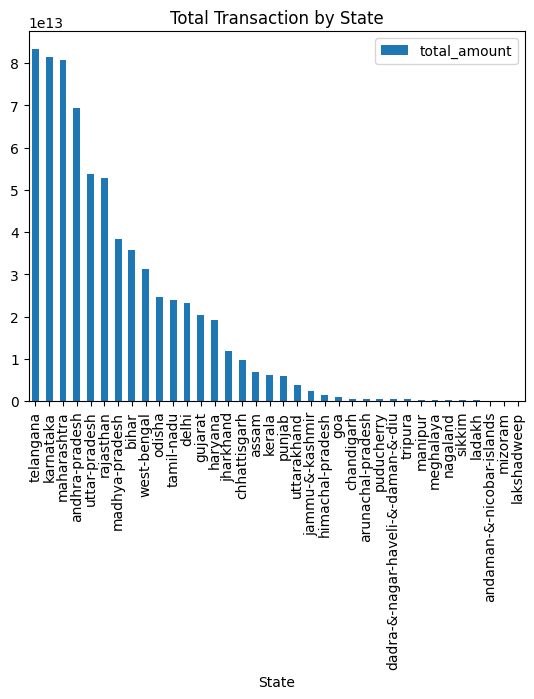

In [119]:
import matplotlib.pyplot as plt

query = """
SELECT state, SUM(Transaction_Amount) as total_amount
FROM Aggregated_Transaction
GROUP BY state
ORDER BY total_amount DESC
"""

df_state = pd.read_sql_query(query, conn)

df_state.plot(kind='bar', x='State', y='total_amount')
plt.title("Total Transaction by State")
plt.xticks(rotation=90)
plt.show()

In [120]:
query_transaction_type = """
SELECT Transaction_Type, SUM(Transaction_Amount) as total_amount
FROM Aggregated_Transaction
GROUP BY Transaction_Type
ORDER BY total_amount DESC;
"""

df_transaction_type_sum = pd.read_sql_query(query_transaction_type, conn)
print(df_transaction_type_sum)

           Transaction_Type  total_amount
0     Peer-to-peer payments  5.330547e+14
1         Merchant payments  1.306798e+14
2  Recharge & bill payments  2.667752e+13
3                    Others  3.485613e+11
4        Financial Services  2.840375e+11


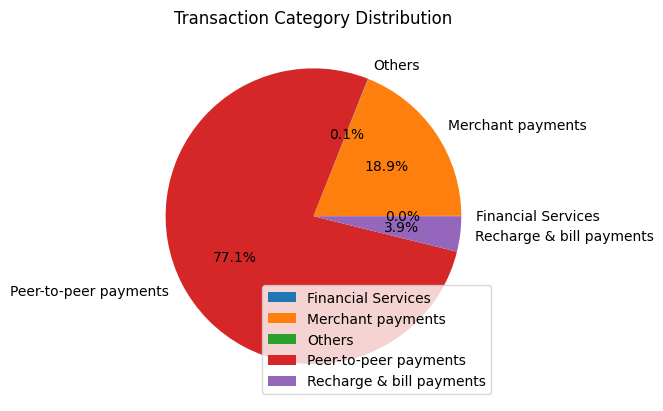

In [121]:
query = """
SELECT Transaction_Type, SUM(Transaction_Amount) as total_amount
FROM Aggregated_Transaction
GROUP BY Transaction_Type
"""

df_cat = pd.read_sql_query(query, conn)

df_cat.plot(kind='pie', y='total_amount', labels=df_cat['Transaction_Type'], autopct='%1.1f%%')
plt.title("Transaction Category Distribution")
plt.ylabel("")
plt.show()

#case2 2. Device Dominance and User Engagement Analysis
Scenario
PhonePe aims to enhance user engagement and improve app performance by understanding user preferences across different device brands. The data reveals the number of registered users and app opens, segmented by device brands, regions, and time periods. However, trends in device usage vary significantly across regions, and some devices are disproportionately underutilized despite high registration numbers.


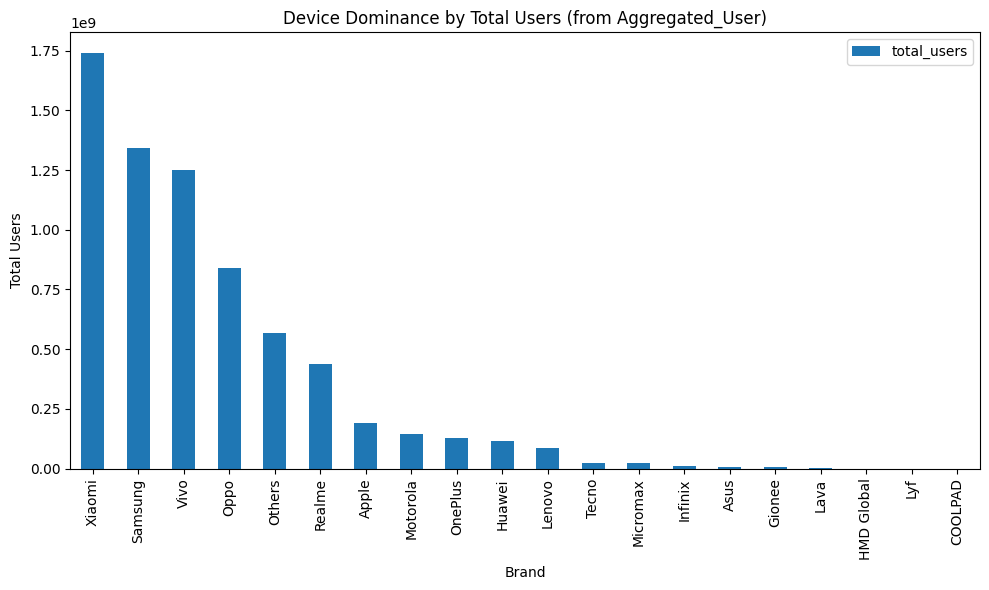

In [122]:


query1 = """
SELECT Brand, SUM(Count) as total_users
FROM Aggregated_User
GROUP BY Brand
ORDER BY total_users DESC
"""

df_device = pd.read_sql_query(query1, conn)

df_device.plot(kind='bar', x='Brand', y='total_users', figsize=(10, 6))

plt.title("Device Dominance by Total Users (from Aggregated_User)")
plt.ylabel("Total Users")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [123]:
# AppOpens is found in the Map_User table, not Aggregated_User
query2 = """
SELECT State, SUM(AppOpens) as total_app_opens
FROM Map_User
GROUP BY State
ORDER BY total_app_opens DESC
"""

df_engagement = pd.read_sql_query(query2, conn)

print(df_engagement)

                                 State  total_app_opens
0                          maharashtra      99232847974
1                            rajasthan      97015260668
2                       madhya-pradesh      79417001592
3                            karnataka      76689758534
4                        uttar-pradesh      66473667368
5                       andhra-pradesh      49456048618
6                            telangana      46395546824
7                              gujarat      41560833960
8                           tamil-nadu      33984398752
9                               odisha      28987846576
10                               bihar      27216518502
11                        chhattisgarh      22380821628
12                         west-bengal      21887637654
13                           jharkhand      21815819604
14                               assam      18873017418
15                             haryana      16518252426
16                              punjab      1028

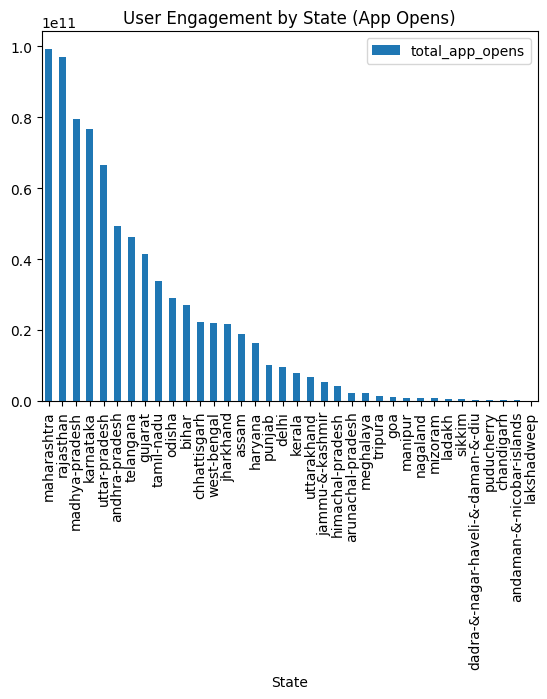

In [124]:
df_engagement.plot(kind='bar', x='State', y='total_app_opens')

plt.title("User Engagement by State (App Opens)")
plt.xticks(rotation=90)

plt.show()

#case 3  Transaction Analysis for Market Expansion
Scenario
PhonePe operates in a highly competitive market, and understanding transaction dynamics at the state level is crucial for strategic decision-making. With a growing number of transactions across different regions, the company seeks to analyze its transaction data to identify trends, opportunities, and potential areas for expansion.


                                 State  total_amount
0                            telangana  8.331191e+13
1                            karnataka  8.135744e+13
2                          maharashtra  8.074839e+13
3                       andhra-pradesh  6.933816e+13
4                        uttar-pradesh  5.377042e+13
5                            rajasthan  5.268647e+13
6                       madhya-pradesh  3.825056e+13
7                                bihar  3.580270e+13
8                          west-bengal  3.116833e+13
9                               odisha  2.452796e+13
10                          tamil-nadu  2.387244e+13
11                               delhi  2.327504e+13
12                             gujarat  2.038581e+13
13                             haryana  1.929007e+13
14                           jharkhand  1.181329e+13
15                        chhattisgarh  9.780945e+12
16                               assam  6.921584e+12
17                              kerala  6.1525

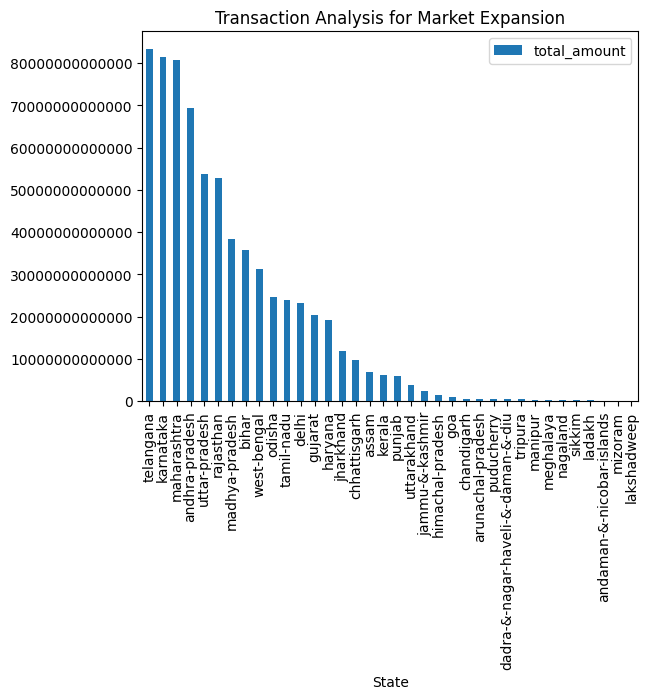

In [125]:
query = """
SELECT state,
       SUM(Transaction_Amount) as total_amount
FROM Aggregated_Transaction
GROUP BY State
ORDER BY total_amount DESC
"""

df_market = pd.read_sql_query(query, conn)

print(df_market)


df_market.plot(kind='bar', x='State', y='total_amount')

ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y')

plt.title("Transaction Analysis for Market Expansion")
plt.xticks(rotation=90)

plt.show()

#case4 6. Insurance Engagement Analysis
Scenario
PhonePe aims to analyze insurance transactions across various states and districts to understand the uptake of insurance services among users. This analysis will provide insights into user behavior, market demand, and potential areas for growth in insurance offerings.


In [126]:
query = """
SELECT State,
       SUM(Insurance_Amount) as total_insurance
FROM Aggregated_Insurance
GROUP BY State
ORDER BY total_insurance DESC
"""

In [127]:
df_insurance = pd.read_sql_query(query, conn)

print(df_insurance)

                                 State  total_insurance
0                            karnataka     5.486310e+09
1                          maharashtra     4.726257e+09
2                        uttar-pradesh     3.480693e+09
3                           tamil-nadu     3.111015e+09
4                               kerala     2.627437e+09
5                            telangana     2.342119e+09
6                          west-bengal     2.104926e+09
7                            rajasthan     1.919308e+09
8                              haryana     1.661962e+09
9                                delhi     1.630730e+09
10                      andhra-pradesh     1.624446e+09
11                             gujarat     1.458467e+09
12                      madhya-pradesh     1.422307e+09
13                               bihar     1.342114e+09
14                              odisha     8.331185e+08
15                               assam     8.236621e+08
16                           jharkhand     6.973

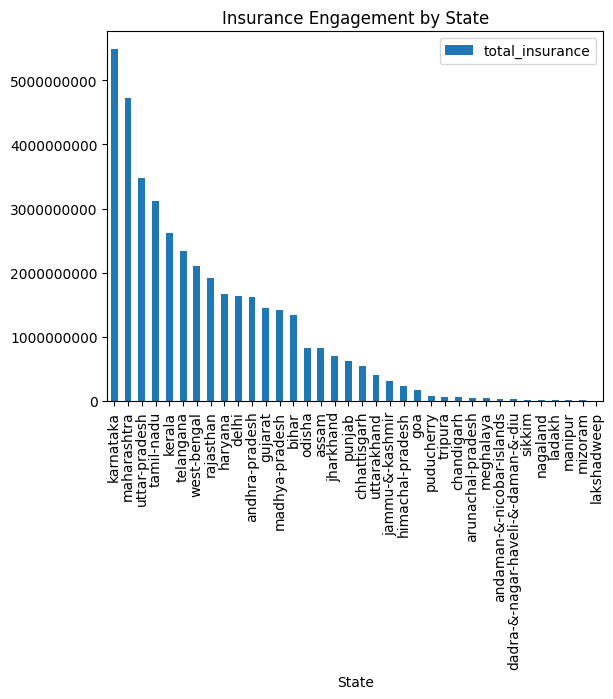

In [128]:

df_insurance.plot(kind='bar', x='State', y='total_insurance')

ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y')

plt.title("Insurance Engagement by State")
plt.xticks(rotation=90)

plt.show()

#  case 5 8. User Registration Analysis
Scenario
PhonePe aims to conduct an analysis of user registration data to identify the top states, districts, and pin codes from which the most users registered during a specific year-quarter combination. This analysis will provide insights into user engagement patterns and highlight potential growth areas.


In [129]:
query = """
SELECT State,
SUM(RegisteredUsers) AS Total_users
FROM Map_User
GROUP BY State
ORDER BY Total_users DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)
df

,State,Total_users
0,maharashtra,2280276486
1,uttar-pradesh,1884668292
2,karnataka,1467348472
3,andhra-pradesh,1113494252
4,rajasthan,1111548986
5,west-bengal,1049928716
6,telangana,1049241040
7,tamil-nadu,1012973544
8,madhya-pradesh,941327248
9,gujarat,918309332


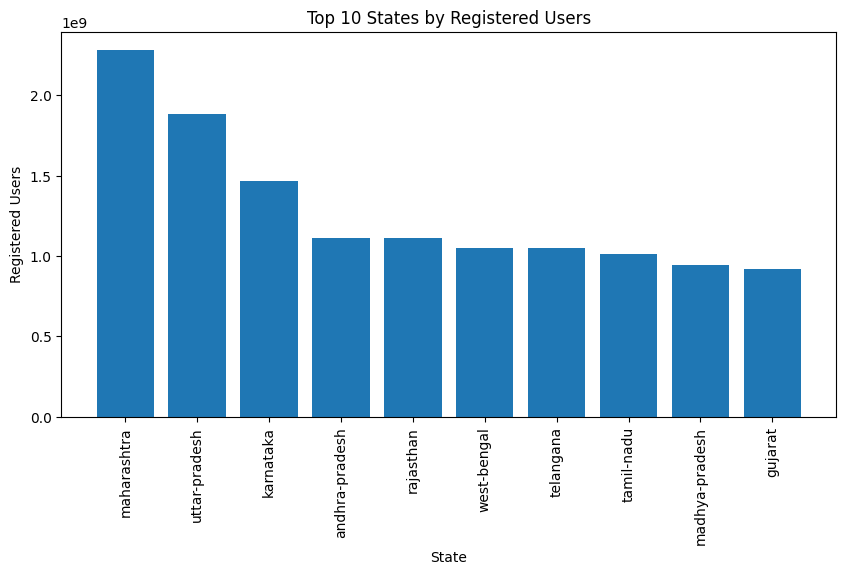

In [130]:

plt.figure(figsize=(10,5))

plt.bar(df["State"], df["Total_users"])

plt.xticks(rotation=90)

plt.title("Top 10 States by Registered Users")

plt.xlabel("State")
plt.ylabel("Registered Users")

plt.show()

In [131]:
# TOP DISTRICTS BY REGISTERED USERS

query2 = """
SELECT District,
SUM(RegisteredUsers) AS Total_users
FROM Map_User
WHERE Year = 2023 AND Quarter = 1
GROUP BY District
ORDER BY Total_users DESC
LIMIT 10;
"""

In [132]:
district_df = pd.read_sql(query2, conn)

print(district_df)




                              District  Total_users
0             bengaluru urban district     30580744
1                        pune district     20074044
2                       thane district     12629236
3                      jaipur district     12494190
4             mumbai suburban district     12191390
5                   hyderabad district     10353798
6                   ahmadabad district      9469260
7                  rangareddy district      8966386
8  north twenty four parganas district      7853948
9                       surat district      7839658


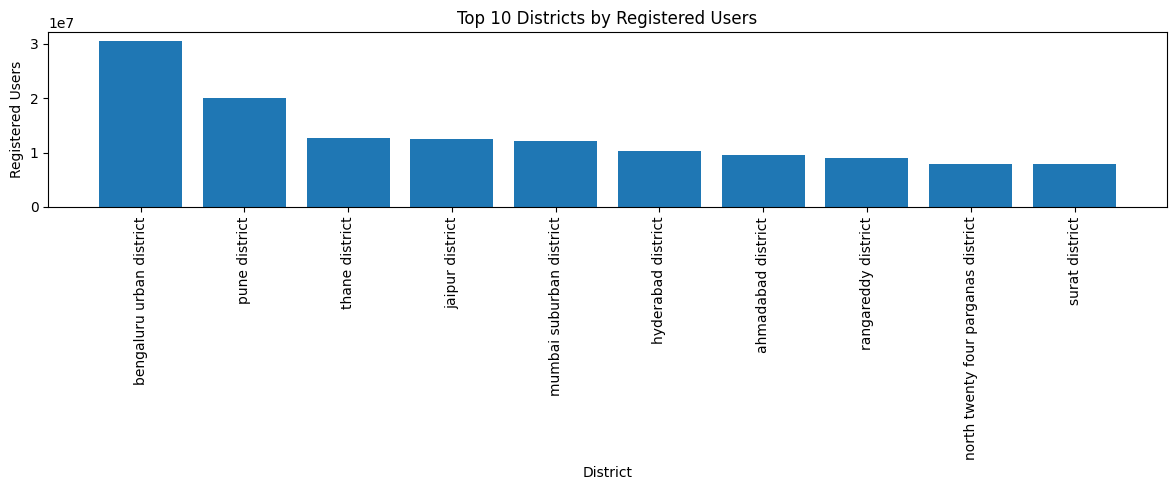

In [133]:
plt.figure(figsize=(12,5))

plt.bar(district_df["District"], district_df["Total_users"])

plt.xticks(rotation=90)

plt.title("Top 10 Districts by Registered Users")

plt.xlabel("District")

plt.ylabel("Registered Users")

plt.tight_layout()

plt.show()

In [134]:
# TOP PINCODES BY REGISTERED USERS

query3 = """
SELECT Pincode,
SUM(RegisteredUsers) AS Total_users
FROM Top_User_Pincodes
WHERE Year = 2023 AND Quarter = 1
GROUP BY Pincode
ORDER BY Total_users DESC
LIMIT 10;
"""

In [135]:
pincode_df = pd.read_sql(query3, conn)

print(pincode_df)



  Pincode  Total_users
0  201301      1702902
1  110059      1433712
2  560068      1316346
3  421302      1272916
4  500072      1141304
5  122001      1133778
6  110092      1114976
7  110086      1000426
8  121004       980486
9  201009       944312


In [136]:
pincode_df = pd.read_sql(query3, conn)

print(pincode_df)

  Pincode  Total_users
0  201301      1702902
1  110059      1433712
2  560068      1316346
3  421302      1272916
4  500072      1141304
5  122001      1133778
6  110092      1114976
7  110086      1000426
8  121004       980486
9  201009       944312


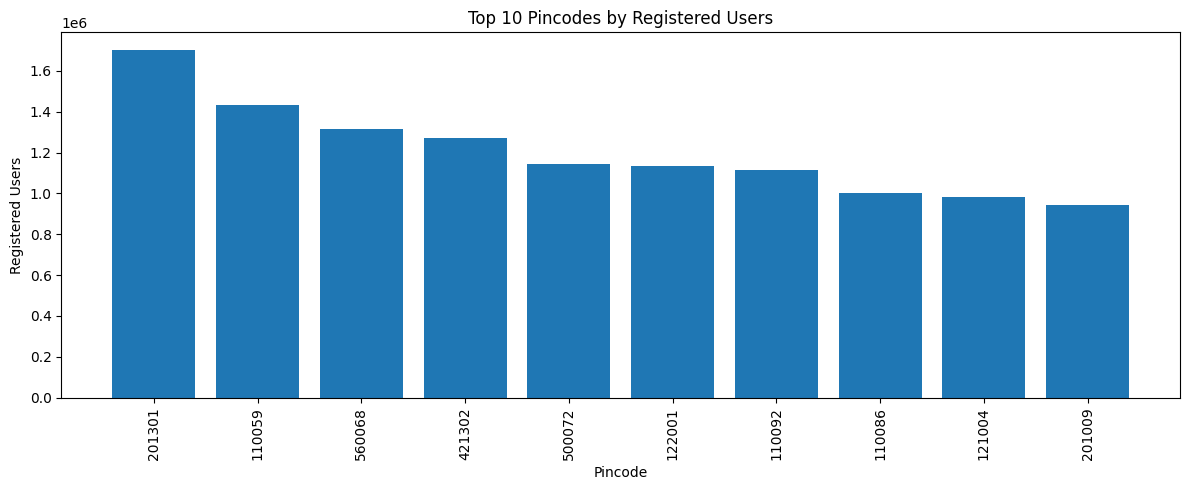

In [137]:
plt.figure(figsize=(12,5))

plt.bar(pincode_df["Pincode"].astype(str),
        pincode_df["Total_users"])

plt.xticks(rotation=90)

plt.title("Top 10 Pincodes by Registered Users")

plt.xlabel("Pincode")

plt.ylabel("Registered Users")

plt.tight_layout()

plt.show()

#map

In [138]:
!pip install plotly

In [139]:
import plotly.express as px

In [140]:
import pandas as pd
import plotly.express as px
import sqlite3

# Updated database connection to match the file created in cell xLI5_NKwg7wq
conn = sqlite3.connect("phonpe_project.bd")

# Corrected SQL query using existing table and column names
query = """
SELECT State,
SUM(RegisteredUsers) AS Total_users
FROM Map_User
WHERE Year = 2023 AND Quarter = 1
GROUP BY State;
"""

df = pd.read_sql(query, conn)

# clean state names to match geojson expectations
df["State"] = df["State"].str.replace("-", " ").str.title()

# INDIA MAP
fig = px.choropleth(
    df,
    geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson",
    featureidkey='properties.ST_NM',
    locations='State',
    color='Total_users',
    color_continuous_scale='Reds',
    title="State Wise Registered Users"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(width=1000, height=700)
fig.show()

#streamlit app

In [141]:
!pip install streamlit plotly pyngrok

In [148]:
%%writefile app.py

import streamlit as st
import pandas as pd
import sqlite3
import plotly.express as px
import matplotlib.pyplot as plt

# PAGE SETTINGS
st.set_page_config(page_title="PhonePe Dashboard", layout="wide")

# DATABASE CONNECTION
conn = sqlite3.connect("phonpe_project.bd")

# TITLE
st.title("PhonePe Transaction Insights")

# SIDEBAR
page = st.sidebar.radio("Navigation", ["Home", "Business Case Study"])

if page == "Home":
    st.header("PhonePe Dashboard Home")
    st.write("""
    This dashboard contains:
    - Transaction Analysis
    - Device Analysis
    - Insurance Analysis
    - Market Expansion
    - User Registration Analysis
    """)

elif page == "Business Case Study":
    st.subheader("Select any Question")
    case = st.selectbox(
        "Choose Business Case Study",
        (
            "1. Decoding Transaction Dynamics on PhonePe",
            "2. Device Dominance and User Engagement Analysis",
            "3. Insurance Penetration and Growth Potential Analysis",
            "4. Transaction Analysis for Market Expansion",
            "5. User Engagement and Growth Strategy"
        )
    )

    col1, col2 = st.columns(2)
    with col1: year = st.selectbox("Year", [2018, 2019, 2020, 2021, 2022, 2023, 2024])
    with col2: quarter = st.selectbox("Quarter", [1, 2, 3, 4])

    if case == "1. Decoding Transaction Dynamics on PhonePe":
        st.markdown("<h1 style='color:red;'>Total Transaction Amount Analysis</h1>", unsafe_allow_html=True)
        query = f"SELECT State, SUM(Transaction_Amount) AS Total_Transaction_Value FROM Aggregated_Transaction WHERE Year = {year} AND Quarter = {quarter} GROUP BY State;"
        df = pd.read_sql(query, conn)
        df["State"] = df["State"].str.replace("-", " ").str.title()
        fig = px.choropleth(df, geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson", featureidkey="properties.ST_NM", locations="State", color="Total_Transaction_Value", hover_name="State", color_continuous_scale="Blues")
        fig.update_geos(fitbounds="locations", visible=False)
        st.plotly_chart(fig, use_container_width=True)
        st.subheader("State Wise Transaction Amount")
        fig2, ax = plt.subplots(figsize=(12,6))
        ax.bar(df["State"], df["Total_Transaction_Value"])
        plt.xticks(rotation=90)
        plt.tight_layout()
        st.pyplot(fig2)

    elif case == "2. Device Dominance and User Engagement Analysis":
        st.markdown("<h1 style='color:red;'>Device Dominance Analysis</h1>", unsafe_allow_html=True)
        query = f"SELECT Brand, SUM(Count) AS Total_Count FROM Aggregated_User WHERE Year = {year} AND Quarter = {quarter} GROUP BY Brand ORDER BY Total_Count DESC LIMIT 10;"
        df = pd.read_sql(query, conn)
        fig = px.pie(df, names="Brand", values="Total_Count", hole=0.5)
        st.plotly_chart(fig)
        st.dataframe(df)

    elif case == "3. Insurance Penetration and Growth Potential Analysis":
        st.markdown("<h1 style='color:red;'>Insurance Growth Analysis</h1>", unsafe_allow_html=True)
        query = f"SELECT State, SUM(Insurance_Amount) AS Total_Insurance FROM Aggregated_Insurance WHERE Year = {year} AND Quarter = {quarter} GROUP BY State;"
        df = pd.read_sql(query, conn)
        df["State"] = df["State"].str.replace("-", " ").str.title()
        fig = px.choropleth(df, geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson", featureidkey="properties.ST_NM", locations="State", color="Total_Insurance", color_continuous_scale="Greens")
        fig.update_geos(fitbounds="locations", visible=False)
        st.plotly_chart(fig)
        st.subheader("State Wise Insurance Amount")
        if not df.empty:
            fig2, ax = plt.subplots(figsize=(12,6))
            ax.bar(df["State"], df["Total_Insurance"], color='teal')
            plt.xticks(rotation=90)
            plt.ylabel("Insurance Amount")
            plt.tight_layout()
            st.pyplot(fig2)
        else:
            st.warning("No data available for the selected Year and Quarter.")

    elif case == "4. Transaction Analysis for Market Expansion":
        st.markdown("<h1 style='color:red;'>Market Expansion Analysis</h1>", unsafe_allow_html=True)
        query = f"SELECT state AS State, SUM(Amount) AS Total_Amount FROM Map_Transaction WHERE year = {year} AND Quarter = {quarter} GROUP BY state ORDER BY Total_Amount DESC LIMIT 10;"
        df = pd.read_sql(query, conn)
        st.subheader("Top 10 States by Transaction Amount")
        fig, ax = plt.subplots(figsize=(12,5))
        ax.bar(df["State"], df["Total_Amount"])
        plt.xticks(rotation=90)
        plt.ylabel("Transaction Amount")
        plt.tight_layout()
        st.pyplot(fig)
        st.dataframe(df)

    elif case == "5. User Engagement and Growth Strategy":
        st.markdown("<h1 style='color:red;'>User Registration Analysis</h1>", unsafe_allow_html=True)
        query = f"SELECT State, SUM(RegisteredUsers) AS Total_Users FROM Map_User WHERE Year = {year} AND Quarter = {quarter} GROUP BY State;"
        df = pd.read_sql(query, conn)
        df["State"] = df["State"].str.replace("-", " ").str.title()
        fig = px.choropleth(df, geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson", featureidkey="properties.ST_NM", locations="State", color="Total_Users", color_continuous_scale="Reds")
        fig.update_geos(fitbounds="locations", visible=False)
        st.plotly_chart(fig)
        st.dataframe(df)


Overwriting app.py


In [149]:
!streamlit run app.py &>/dev/null&

In [150]:
from pyngrok import ngrok

ngrok.set_auth_token("3D1gKUjT4FxghAQMeM2toSrvny8_2E17xUa9cnKs2bSy8Uktp")

public_url = ngrok.connect(8501)
print(f"Streamlit App Link: {public_url}")

Streamlit App Link: NgrokTunnel: "https://grouped-unnerving-handshake.ngrok-free.dev" -> "http://localhost:8501"
